In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AffinityPropagation
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import pairwise_distances
import seaborn as sns
from itertools import cycle
from scipy.stats import chi2_contingency
from sklearn.metrics.cluster import contingency_matrix

In [2]:
def plot_ap_clusters(X_pca, ap, num_genes):
    cluster_centers_indices = ap.cluster_centers_indices_
    labels = ap.labels_
    n_clusters = len(cluster_centers_indices)

    plt.figure(figsize=(7,6))
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

    for k, col in zip(range(n_clusters), colors):
        class_members = (labels == k)
        cluster_center = X_pca[cluster_centers_indices[k]]
        
        # connect each point to its exemplar
        plt.plot(X_pca[class_members, 0], X_pca[class_members, 1], '.', color=col)
        for x in X_pca[class_members]:
            plt.plot([cluster_center[0], x[0]], [cluster_center[1], x[1]], color=col, alpha=0.3)
        
        # plot the exemplar
        plt.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,
                markeredgecolor='k', markersize=8)

    plt.title(f'Affinity Propagation Clustering w/ {num_genes} Most Variable Genes\nNumber of clusters: {n_clusters}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.savefig(f'../results/figures/assignment-3/affinity_propagation_clustering_{num_genes}_genes.png')
    plt.show()

In [6]:
def cluster_ap(expression_data, gene_variances, num_genes):
    top_variable_genes = gene_variances.sort_values(ascending=False).head(num_genes).index
    top_variable_expression = expression_data.loc[top_variable_genes]
    data_for_clustering = top_variable_expression.T  # samples as rows, genes as columns

    # load the data
    X = data_for_clustering.values

    # filter out constant (no-variance) genes
    selector = VarianceThreshold()  # default threshold=0 removes constant genes
    X_var = selector.fit_transform(X)

    # standardize the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_var)

    # dimensionality reduction via PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    print(f"PCA reduced to {X_pca.shape[1]} components, explaining {np.sum(pca.explained_variance_ratio_):.2%} variance")

    # compute similarity matrix
    similarity = -pairwise_distances(X_pca, metric='euclidean')

    # run affinity propagation clustering
    ap = AffinityPropagation(affinity='euclidean', damping=0.5, random_state=3)
    ap.fit(similarity)

    labels = ap.labels_
    cluster_centers = ap.cluster_centers_indices_
    n_clusters = len(cluster_centers)

    print(f"✅ Found {n_clusters} clusters")

    # plot affinity propagation clusters
    plot_ap_clusters(X_pca, ap, num_genes)

    return data_for_clustering, labels

PCA reduced to 2 components, explaining 34.93% variance
✅ Found 10 clusters


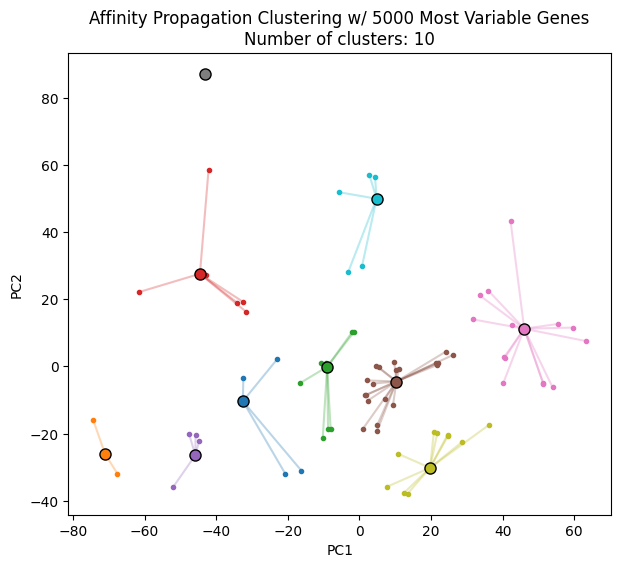

In [7]:
expression_data = pd.read_csv('expression_data.csv')
gene_variances = expression_data.var(axis=1)
data_for_clustering, cluster_labels = cluster_ap(expression_data, gene_variances, 5000)

In [8]:
# save clustering results to .csv for use in assignment 4

samples = data_for_clustering.index

cluster_df = pd.DataFrame({
    'Sample': samples,
    'Cluster_AP': cluster_labels
})
cluster_df.to_csv('../results/cluster_results_ap.csv', index=False)

PCA reduced to 2 components, explaining 55.82% variance
✅ Found 11 clusters


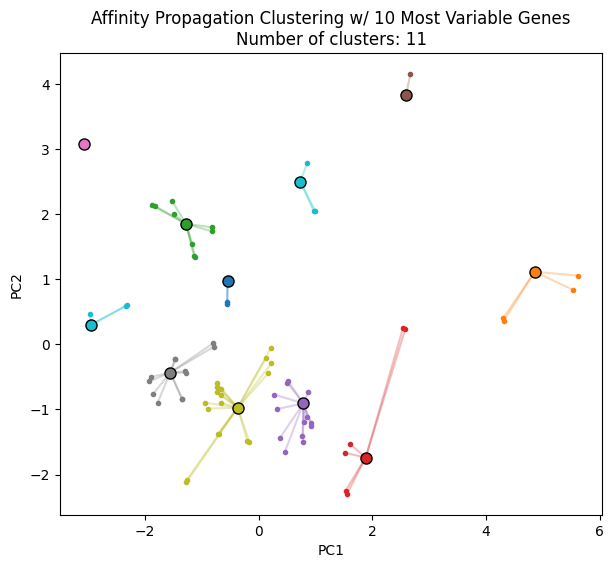

PCA reduced to 2 components, explaining 41.71% variance
✅ Found 11 clusters


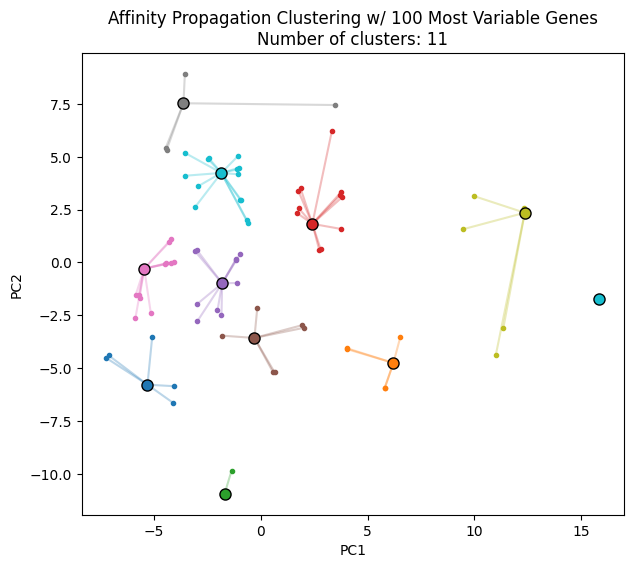

PCA reduced to 2 components, explaining 36.40% variance
✅ Found 9 clusters


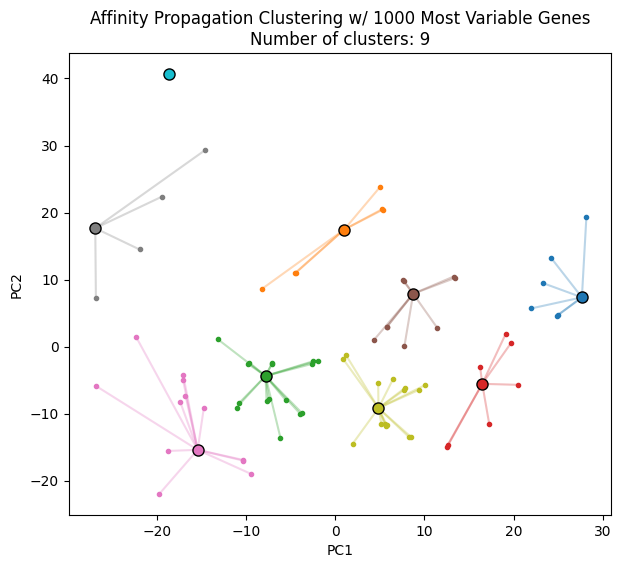

PCA reduced to 2 components, explaining 28.99% variance
✅ Found 10 clusters


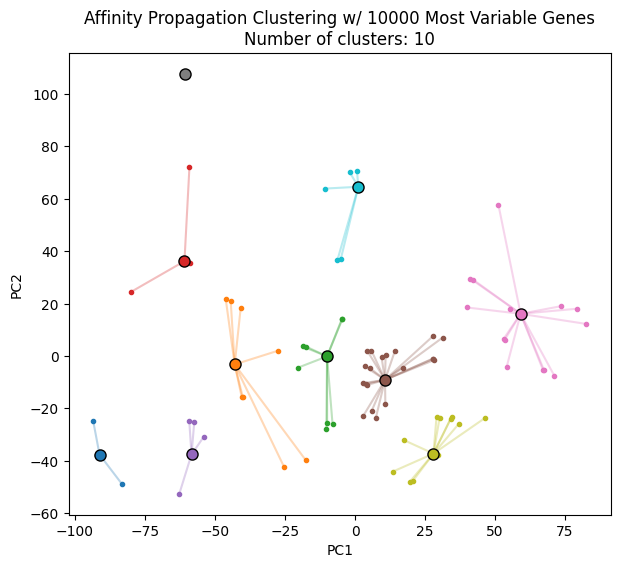

In [5]:
# cluster with different numbers of genes
top_n_list = [10, 100, 1000, 10000]
labels_dict = {}
for n in top_n_list:
       labels_dict[n] = cluster_ap(expression_data, gene_variances, n)

In [6]:
# perform chi-squared test on each pair of clustering results
results = []
for i, n1 in enumerate(top_n_list):
    for n2 in top_n_list[i+1:]:
        contingency = pd.crosstab(labels_dict[n1], labels_dict[n2])
        chi2, p, _, _ = chi2_contingency(contingency)
        results.append({'Genes 1': n1, 'Genes 2': n2, 'Chi2 Statistic': chi2, 'p-value': p})
print(pd.DataFrame(results))

   Genes 1  Genes 2  Chi2 Statistic       p-value
0       10      100      262.258200  1.716634e-16
1       10     1000      203.046435  1.153208e-12
2       10    10000      196.266689  7.060302e-10
3      100     1000      400.171414  4.317572e-44
4      100    10000      314.332037  1.259026e-26
5     1000    10000      337.051349  6.754210e-36
